Choose Adult Income CSV file:


Saving adult.csv to adult (3).csv

First 5 Rows:
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K

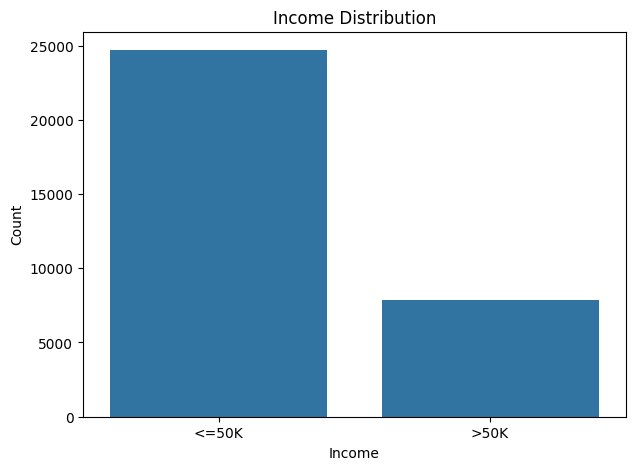


Dataset After Feature Engineering:
   age workclass  fnlwgt     education  education_num marital_status  \
0   90   Private   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66   Private  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital_gain  \
0     Prof-specialty  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2     Prof-specialty      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital_loss  hours_per_week native_country income    age_group  \
0          4356              40  United-States  <=50

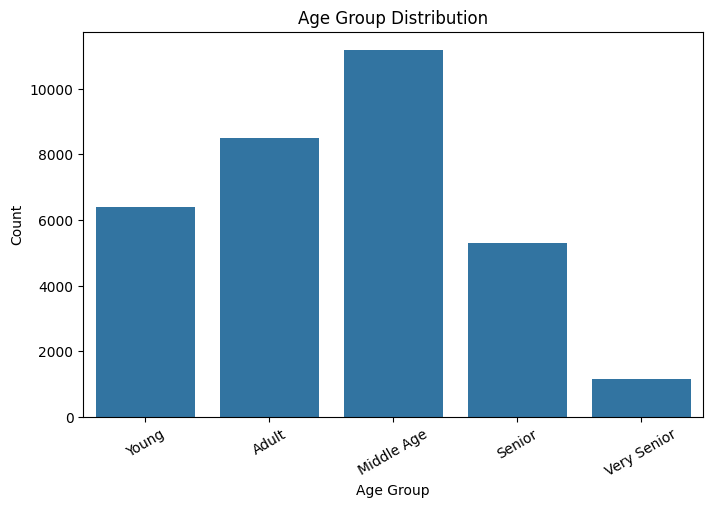

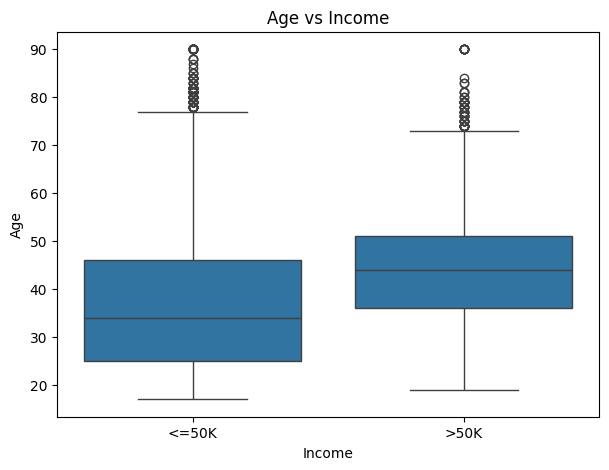

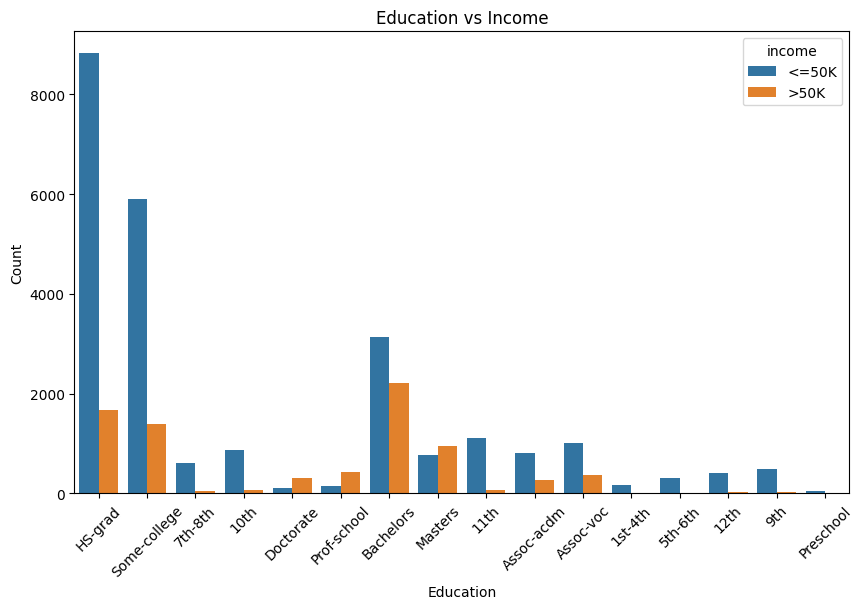

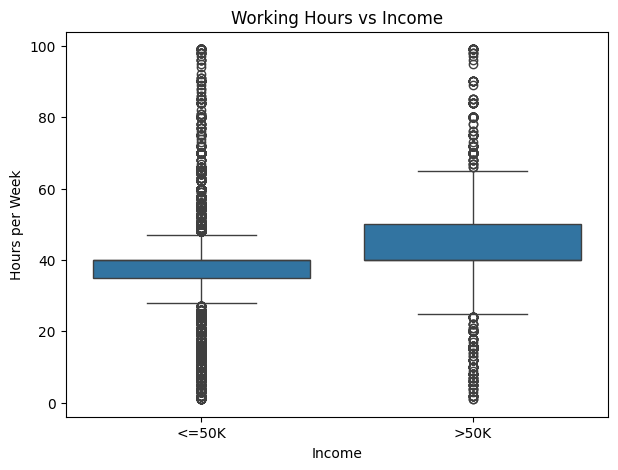

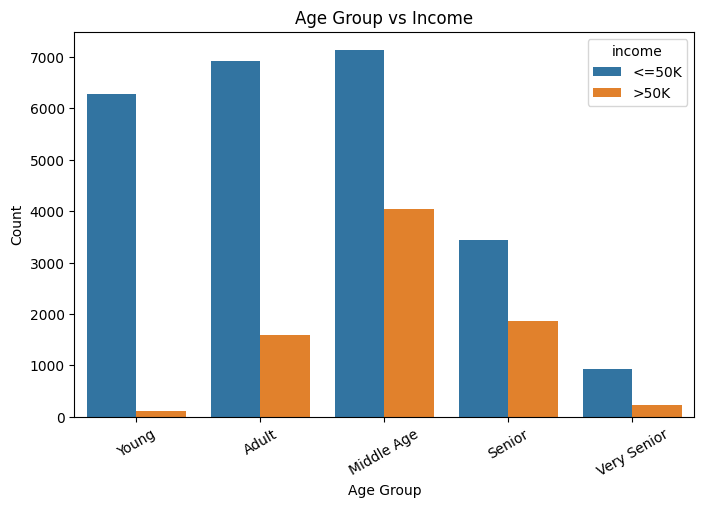

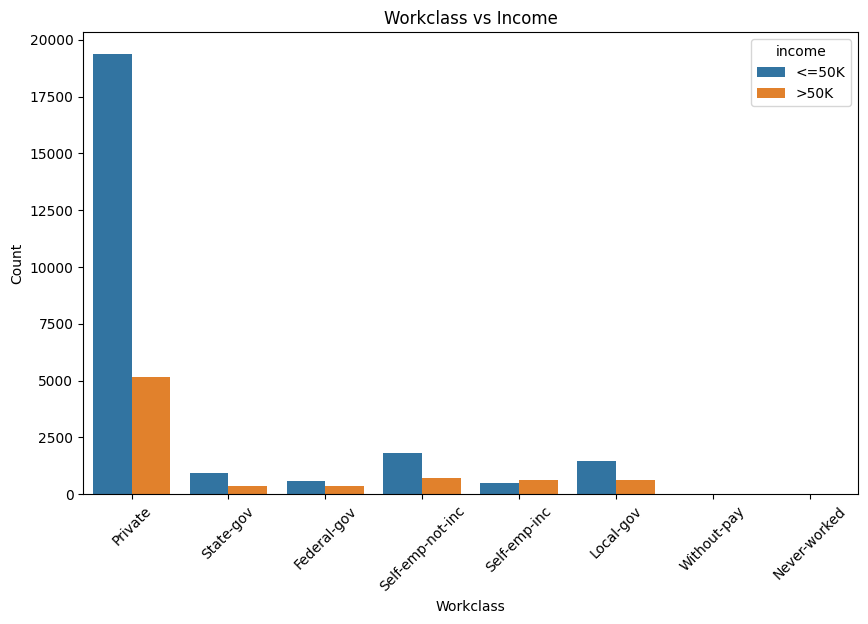

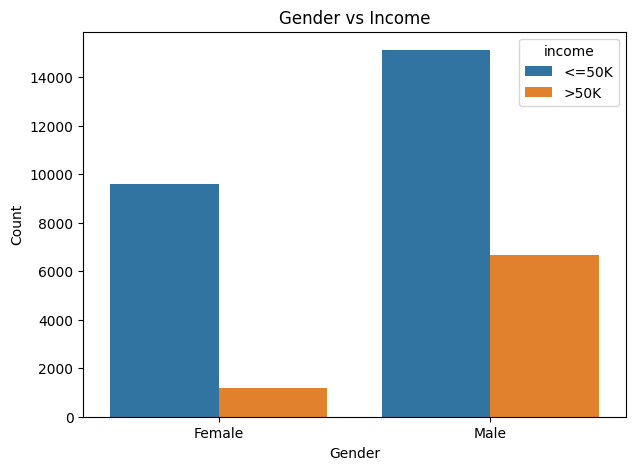

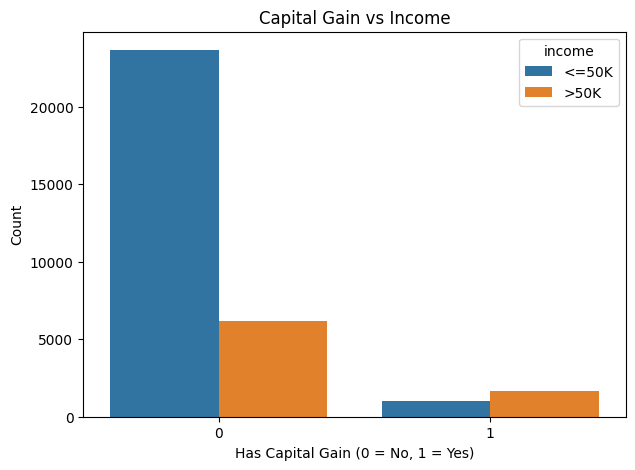

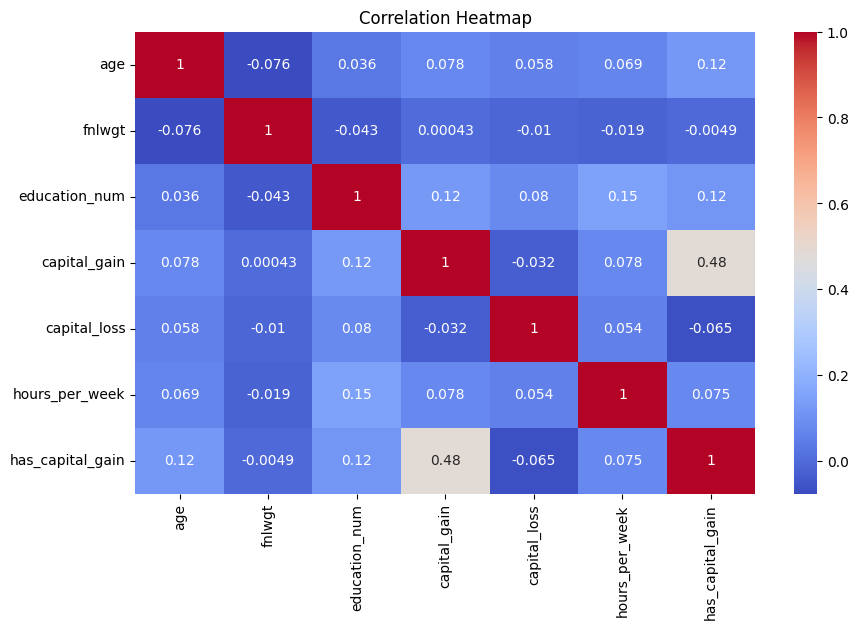


PROGRAM COMPLETED SUCCESSFULLY
File: adult_income_engineered.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# ============================================================
# PROGRAM 3: ADULT INCOME
# FEATURE ENGINEERING AND EDA
# ============================================================

# 1. Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# 2. Upload CSV file
# ============================================================

print("Choose Adult Income CSV file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(filename)

# ============================================================
# 3. Display original dataset
# ============================================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# ============================================================
# 4. Clean column names
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(".", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

print("\nCleaned Column Names:")
print(df.columns.tolist())

# ============================================================
# 5. Replace ? with NaN
# ============================================================

df = df.replace("?", np.nan)

# ============================================================
# 6. Check missing values
# ============================================================

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# ============================================================
# 7. Handle missing values
# ============================================================

# Numerical columns → median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → mode
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ============================================================
# 8. Remove duplicate rows
# ============================================================

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

# ============================================================
# 9. Income Distribution
# ============================================================

print("\nIncome Distribution:")
print(df["income"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="income")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

# ============================================================
# 10. FEATURE ENGINEERING
# ============================================================

# Create Age Group
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=[
        "Young",
        "Adult",
        "Middle Age",
        "Senior",
        "Very Senior"
    ]
)

# Create Working Hours Category
df["work_hours_category"] = pd.cut(
    df["hours_per_week"],
    bins=[0, 40, 60, 100],
    labels=[
        "Part-time",
        "Full-time",
        "Overtime"
    ]
)

# Create Capital Gain Indicator
df["has_capital_gain"] = np.where(
    df["capital_gain"] > 0,
    1,
    0
)

print("\nDataset After Feature Engineering:")
print(df.head())

# ============================================================
# 11. Age Group Distribution
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="age_group"
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

# ============================================================
# 12. Age vs Income
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="income",
    y="age"
)

plt.title("Age vs Income")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()

# ============================================================
# 13. Education vs Income
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="education",
    hue="income"
)

plt.title("Education vs Income")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 14. Working Hours vs Income
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="income",
    y="hours_per_week"
)

plt.title("Working Hours vs Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.show()

# ============================================================
# 15. Age Group vs Income
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="age_group",
    hue="income"
)

plt.title("Age Group vs Income")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

# ============================================================
# 16. Workclass vs Income
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="workclass",
    hue="income"
)

plt.title("Workclass vs Income")
plt.xlabel("Workclass")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 17. Gender vs Income
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sex",
    hue="income"
)

plt.title("Gender vs Income")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# ============================================================
# 18. Capital Gain vs Income
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="has_capital_gain",
    hue="income"
)

plt.title("Capital Gain vs Income")
plt.xlabel("Has Capital Gain (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# ============================================================
# 19. Correlation Heatmap
# ============================================================

numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# 20. Save Feature-Engineered Dataset
# ============================================================

df.to_csv(
    "adult_income_engineered.csv",
    index=False
)

print("\n======================================")
print("PROGRAM COMPLETED SUCCESSFULLY")
print("File: adult_income_engineered.csv")
print("======================================")

# Download the file
files.download("adult_income_engineered.csv")